In [1]:
import mpmath as mp
import numpy as np
import scipy as spy
import matplotlib.pyplot as plt
import timeit
from libMilne import *

/home/andrea/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [7]:
fermi_minor_part(τ, μ, mass, px, py, β, SP)

matrix(
[['0.269191131536937', '0.0'],
 ['0.0', '0.463888258113936']])

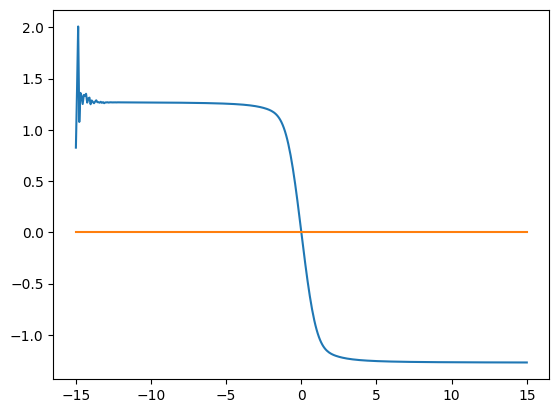

In [10]:
mass, px, py, μ, τ,SP,β = 0.7,0.3,0.2,-1,1,-1,0.4
mus = np.linspace(-15,15,400)
mptr = [sw(τ, x, mass, px, py) for x in mus]
tr = to_numpy(mptr)
plt.plot(mus,np.real(tr))
plt.plot(mus,np.imag(tr))

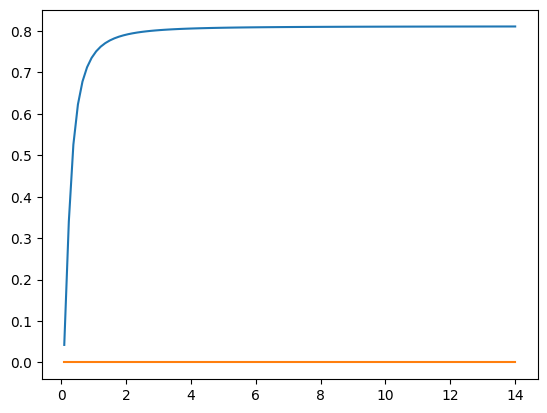

In [56]:
mass, px, py, μ, τ,SP,β = 0.7,0.5,0.5,-1,1,-1,0.4
mus = np.linspace(0.1,14,100)
mptr = [np.trace(numpy_Adag_A(x, μ, mass,px, py, β, SP)) for x in mus]
tr = to_numpy(mptr)
plt.plot(mus,np.real(tr))
plt.plot(mus,np.imag(tr))

In [12]:
import scipy.integrate as spi

# Define the function to integrate
def f0(x):
    return np.trace(numpy_Adag_A(τ, x, mass,px, py, β, SP))

def f1(x):
    return np.trace(np.dot(to_numpy(pauli_matrices(1)),numpy_Adag_A(τ, x, mass,px, py, β, SP)))

def f2(x):
    return np.trace(np.dot(to_numpy(pauli_matrices(2)),numpy_Adag_A(τ, x, mass,px, py, β, SP)))

def f3(x):
    return np.trace(np.dot(to_numpy(pauli_matrices(3)),numpy_Adag_A(τ, x, mass,px, py, β, SP)))




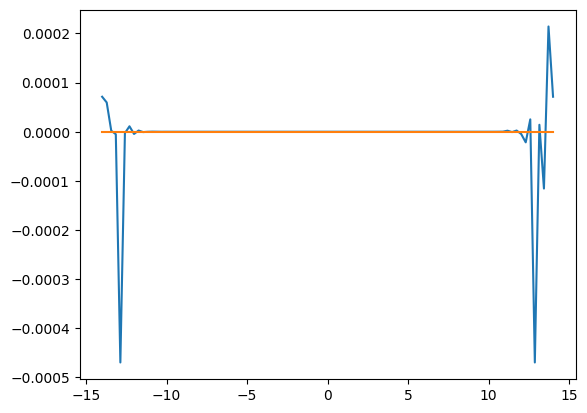

In [16]:
mass, px, py, μ, τ,SP,β = 0.7,1,-0.5,-1,1,-1,0.4
mus = np.linspace(-14,14,100)
mptr = [f2(x)+f2(-x) for x in mus]
tr = to_numpy(mptr)
plt.plot(mus,np.real(tr))
plt.plot(mus,np.imag(tr))

In [17]:
SPlist = [0.1,0.5,1,1.5,2,3]
den = []
num = []
for s in SPlist:
    SP = s
    result, error = spi.quad(f0, 0.01, 14)
    resultn, nerror = spi.quad(f3, 0.01, 14)
    den.append(result)
    num.append(resultn)

num = np.array(num)
den = np.array(den)

/home/andrea/.local/lib/python3.12/site-packages/scipy/integrate/_quadpack_py.py:606: ComplexWarning: Casting complex values to real discards the imaginary part
  return _quadpack._qagse(func,a,b,args,full_output,epsabs,epsrel,limit)
/tmp/ipykernel_11633/1758454323.py:6: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  result, error = spi.quad(f0, 0.01, 14)
/tmp/ipykernel_11633/1758454323.py:7: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine t

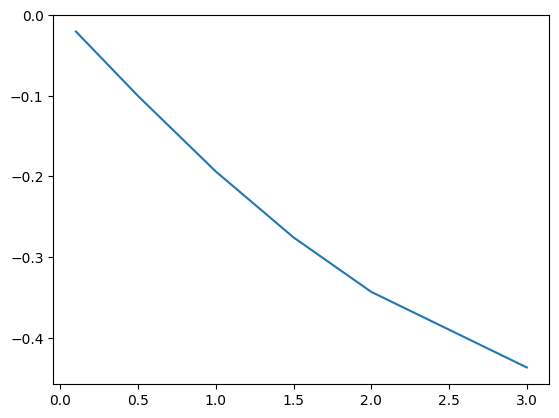

In [18]:
plt.plot(SPlist, num/den)

In [2]:
mass, px, py, μ, τ,SP,β = 0.7,0.1,0.,-1,1,-1,0.4
U,Ud = mpmath_U_and_Udagger_matrices(τ, μ, mass, px, py, β, SP)
H = Htot(τ, μ, mass, px, py, β, SP)


In [4]:
tol=1e-14#np.finfo(np.float64).eps
D=to_numpy(Ud*H*U)
D.real[np.abs(D.real)<tol]=0
D.imag[np.abs(D.imag)<tol]=0
print(D)

[[ 0.9890714 +0.j  0.        +0.j  0.        +0.j  0.        +0.j]
 [ 0.        +0.j  0.04168663+0.j  0.        +0.j  0.        +0.j]
 [ 0.        +0.j  0.        +0.j -0.9890714 +0.j  0.        +0.j]
 [ 0.        +0.j  0.        +0.j  0.        +0.j -0.04168663+0.j]]


# Speed testing

In [3]:

def a():
    return Odag_O(τ, μ, mass, px, py, β, SP)
def b():
    return Adag_A(τ, μ, mass, px, py, β, SP)

print (timeit.timeit(a, number=100))
print (timeit.timeit(b, number=100))



2.2754262470007234
2.1093365420019836


In [10]:
n = 200**3
tsec = (n/(100/2.1093365420019836))
th = tsec/3600
print(tsec,"\n",th)

168746.9233601587 
 46.87414537782186
